# RIAWELC Weld Defect Benchmarking

Benchmark Qwen2.5-VL-3B on 4-class weld defect classification from X-ray radiographs.

**Dataset:** RIAWELC — 24,407 images (227×227 grayscale), 4 classes

**Test set:** 2,443 images (pre-split testing folder)

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

test_dir = '../../datasets/riawelc/testing'
if os.path.isdir(test_dir):
    total = sum(len(os.listdir(os.path.join(test_dir, c))) for c in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, c)))
    print(f'Dataset found: {total} test images in {test_dir}')
else:
    print('Dataset not found. Extract RIAWELC to ../../datasets/riawelc/')

Dataset found: 2443 test images in ../../datasets/riawelc/testing


## Setup

In [2]:
import os, json, re, time, torch, gc
import numpy as np
from PIL import Image
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from config import *

print(f'Test dir: {TEST_IMAGES_DIR}')
print(f'Reference image: {REF_IMAGE_PATH} (exists: {os.path.exists(REF_IMAGE_PATH)})')
for i in range(torch.cuda.device_count()):
    print(f'GPU {i}: {torch.cuda.get_device_name(i)} — {torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB')

Test dir: ../../datasets/riawelc/testing
Reference image: riawelc_reference_grid.png (exists: True)
GPU 0: Tesla V100-PCIE-16GB — 16.9 GB
GPU 1: Tesla V100-PCIE-16GB — 16.9 GB


## Build Manifest

In [3]:
# Build manifest from testing folder
# 2,443 test images is a lot — we'll use a stratified subsample for speed
import random
random.seed(42)

SAMPLE_PER_CLASS = 60  # 60 per class = 240 total (like NEU-CLS), set to None for all

manifest = []
for cls in CLASSES:
    cls_dir = os.path.join(TEST_IMAGES_DIR, cls)
    if not os.path.isdir(cls_dir):
        print(f'WARNING: {cls_dir} not found'); continue
    images = sorted([f for f in os.listdir(cls_dir) if f.endswith('.png')])
    if SAMPLE_PER_CLASS and len(images) > SAMPLE_PER_CLASS:
        images = random.sample(images, SAMPLE_PER_CLASS)
    for img in images:
        manifest.append({'image': os.path.join(cls_dir, img), 'class': cls})

random.shuffle(manifest)
print(f'Test manifest: {len(manifest)} images')
cls_counts = Counter(e['class'] for e in manifest)
for cls in CLASSES:
    print(f'  {cls}: {cls_counts.get(cls, 0)}')

Test manifest: 240 images
  lack_of_penetration: 60
  porosity: 60
  cracks: 60
  no_defect: 60


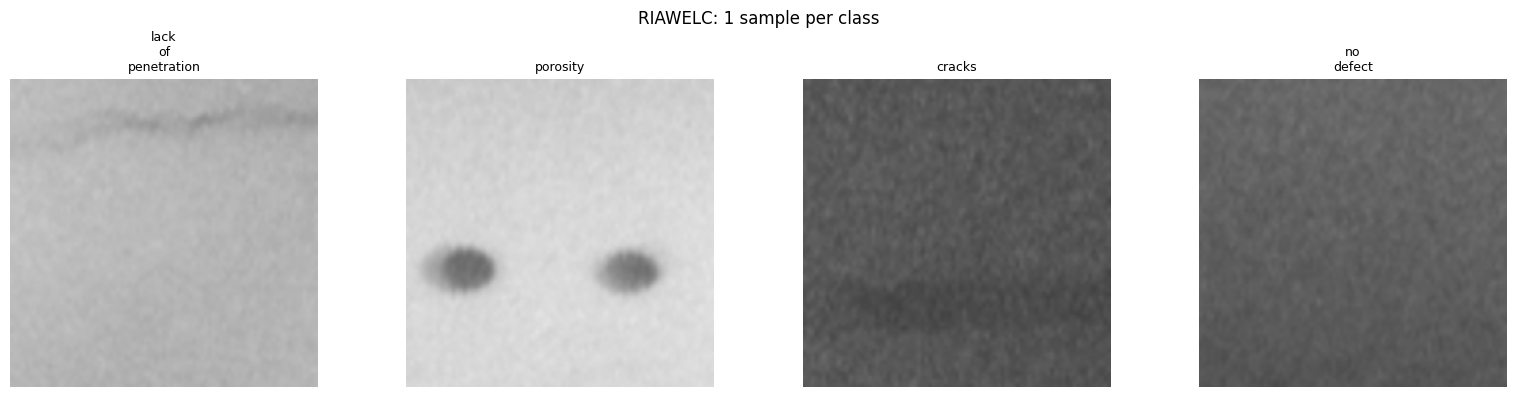

In [4]:
# Preview: 1 image per class
fig, axes = plt.subplots(1, len(CLASSES), figsize=(16, 4))
for i, cls in enumerate(CLASSES):
    entry = next((e for e in manifest if e['class'] == cls), None)
    if entry:
        img = Image.open(entry['image']).convert('RGB')
        axes[i].imshow(img, cmap='gray'); axes[i].set_title(cls.replace('_', '\n'), fontsize=9); axes[i].axis('off')
        img.close()
plt.suptitle('RIAWELC: 1 sample per class', fontsize=12)
plt.tight_layout(); plt.show()

Reference image loaded: (2050, 595)


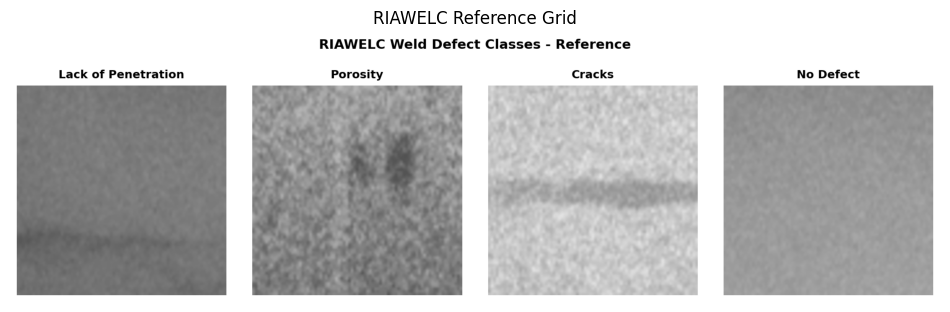

In [5]:
# Load reference image
ref_image = None
if os.path.exists(REF_IMAGE_PATH):
    ref_image = Image.open(REF_IMAGE_PATH).convert('RGB')
    print(f'Reference image loaded: {ref_image.size}')
    plt.figure(figsize=(12, 4))
    plt.imshow(ref_image); plt.title('RIAWELC Reference Grid'); plt.axis('off'); plt.show()
else:
    print(f'WARNING: {REF_IMAGE_PATH} not found')

## Load Model

In [6]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=256*28*28, max_pixels=512*28*28, use_fast=False)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID, dtype=torch.bfloat16, device_map='auto',
    max_memory={0: '6GiB', 1: '15GiB'})
print('Model loaded.')

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.23it/s]


Model loaded.


## Helpers

In [7]:
def parse_response(raw):
    if not raw: return None
    raw = raw.replace('<','').replace('>','')
    raw = re.sub(r'```json\s*','',raw); raw = re.sub(r'```\s*','',raw).strip()
    try:
        obj = json.loads(raw)
        if isinstance(obj, dict): return obj
    except: pass
    m = re.search(r'\{.*\}', raw, re.DOTALL)
    if m:
        try: return json.loads(m.group())
        except: pass
    dm = re.search(r'"defect_class"\s*:\s*"([\w]+)"', raw)
    if dm: return {'defect_class': dm.group(1)}
    raw_lower = raw.lower()
    for cls in sorted(CLASSES, key=len, reverse=True):
        if cls in raw_lower: return {'defect_class': cls}
    return None

def infer(img_path, mode='zero-shot', ref_img=None):
    image = Image.open(img_path).convert('RGB')
    if mode == 'few-shot' and ref_img is not None:
        msgs = [{'role':'user','content':[
            {'type':'image','image':ref_img},
            {'type':'text','text':make_prompt_fs_ref()},
            {'type':'image','image':image},
            {'type':'text','text':make_prompt_fs_query()},
        ]}]
        images = [ref_img, image]
    else:
        msgs = [{'role':'user','content':[
            {'type':'image','image':image},
            {'type':'text','text':make_prompt_zs()},
        ]}]
        images = [image]
    text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=images, return_tensors='pt', padding=True).to(model.device)
    t = time.time()
    with torch.no_grad():
        ids = model.generate(**inputs, max_new_tokens=64, temperature=0.7, do_sample=True)
    elapsed = time.time() - t
    out = processor.batch_decode(ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0].strip()
    del inputs, ids; image.close(); torch.cuda.empty_cache()
    return out, elapsed

def run_benchmark(manifest, mode, ref_img=None, limit=None):
    data = manifest[:limit] if limit else manifest
    results=[]; correct=0; valid=0; tt=0
    for i, entry in enumerate(data):
        raw, elapsed = infer(entry['image'], mode=mode, ref_img=ref_img)
        tt += elapsed
        parsed = parse_response(raw)
        gt = entry['class']
        ok = False
        if parsed:
            valid += 1
            pred = parsed.get('defect_class', '').lower().strip()
            if pred == gt: ok = True; correct += 1
        results.append({'image': entry['image'], 'class': gt, 'predicted': parsed,
            'raw': raw, 'correct': ok, 'valid_json': parsed is not None, 'time_s': round(elapsed, 2)})
        if (i+1) % 30 == 0:
            n = i+1
            print(f'  [{n}/{len(data)}] Acc: {correct}/{n} ({correct/n*100:.0f}%) | JSON: {valid}/{n}')
    return results, correct, valid, tt

print('Helpers ready.')

Helpers ready.


## Quick Test (1 per class)

In [8]:
quick = []
for cls in CLASSES:
    entry = next((e for e in manifest if e['class'] == cls), None)
    if entry: quick.append(entry)

for mode in ['zero-shot', 'few-shot']:
    print(f'\n{"="*55}')
    print(f'Quick test — {mode}')
    print(f'{"="*55}')
    ri = ref_image if mode == 'few-shot' else None
    for entry in quick:
        raw, elapsed = infer(entry['image'], mode=mode, ref_img=ri)
        parsed = parse_response(raw)
        gt = entry['class']
        pred = parsed.get('defect_class', '?') if parsed else '?'
        ok = '✓' if pred == gt else '✗'
        print(f'  {gt:>22} → {pred:<22} {ok} ({elapsed:.1f}s)')


Quick test — zero-shot
     lack_of_penetration → no_defect              ✗ (3.2s)
                porosity → no_defect              ✗ (2.0s)
                  cracks → no_defect              ✗ (1.9s)
               no_defect → no_defect              ✓ (2.0s)

Quick test — few-shot
     lack_of_penetration → lack_of_penetration    ✓ (3.0s)
                porosity → porosity               ✓ (2.7s)
                  cracks → no_defect              ✗ (3.1s)
               no_defect → no_defect              ✓ (3.1s)


## Full Benchmark — Zero-Shot

In [9]:
print('Running zero-shot...')
zs_results, zs_correct, zs_valid, zs_time = run_benchmark(manifest, 'zero-shot')
n = len(zs_results)
print(f'\nZero-shot: Acc={zs_correct}/{n} ({zs_correct/n*100:.1f}%) | JSON={zs_valid}/{n} | Time={zs_time/n:.1f}s/img')

Running zero-shot...
  [30/240] Acc: 11/30 (37%) | JSON: 30/30
  [60/240] Acc: 20/60 (33%) | JSON: 60/60
  [90/240] Acc: 29/90 (32%) | JSON: 90/90
  [120/240] Acc: 38/120 (32%) | JSON: 120/120
  [150/240] Acc: 46/150 (31%) | JSON: 150/150
  [180/240] Acc: 57/180 (32%) | JSON: 180/180
  [210/240] Acc: 64/210 (30%) | JSON: 210/210
  [240/240] Acc: 74/240 (31%) | JSON: 240/240

Zero-shot: Acc=74/240 (30.8%) | JSON=240/240 | Time=2.1s/img


## Full Benchmark — Few-Shot

In [10]:
print('Running few-shot...')
fs_results, fs_correct, fs_valid, fs_time = run_benchmark(manifest, 'few-shot', ref_img=ref_image)
n = len(fs_results)
print(f'\nFew-shot: Acc={fs_correct}/{n} ({fs_correct/n*100:.1f}%) | JSON={fs_valid}/{n} | Time={fs_time/n:.1f}s/img')

Running few-shot...
  [30/240] Acc: 20/30 (67%) | JSON: 30/30
  [60/240] Acc: 32/60 (53%) | JSON: 60/60
  [90/240] Acc: 49/90 (54%) | JSON: 90/90
  [120/240] Acc: 66/120 (55%) | JSON: 120/120
  [150/240] Acc: 80/150 (53%) | JSON: 150/150
  [180/240] Acc: 91/180 (51%) | JSON: 180/180
  [210/240] Acc: 109/210 (52%) | JSON: 210/210
  [240/240] Acc: 123/240 (51%) | JSON: 240/240

Few-shot: Acc=123/240 (51.2%) | JSON=240/240 | Time=2.9s/img


## Results

In [11]:
n = len(zs_results)
print(f'{"Method":<20} {"Accuracy":>10} {"JSON Valid":>12} {"Time/img":>10}')
print('=' * 54)
print(f'{"Qwen ZS":<20} {zs_correct/n*100:>9.1f}% {zs_valid/n*100:>11.0f}% {zs_time/n:>9.1f}s')
print(f'{"Qwen FS":<20} {fs_correct/n*100:>9.1f}% {fs_valid/n*100:>11.0f}% {fs_time/n:>9.1f}s')
print(f'{"Random chance":<20} {100/4:>9.1f}%')

print(f'\nPer-class accuracy:')
print(f'{"Class":<24} {"ZS":>8} {"FS":>8}')
print('-' * 42)
for cls in CLASSES:
    zs_cls = [r for r in zs_results if r['class'] == cls]
    fs_cls = [r for r in fs_results if r['class'] == cls]
    zs_c = sum(1 for r in zs_cls if r['correct'])
    fs_c = sum(1 for r in fs_cls if r['correct'])
    print(f'{cls:<24} {zs_c:>3}/{len(zs_cls)} {fs_c:>3}/{len(fs_cls)}')

Method                 Accuracy   JSON Valid   Time/img
Qwen ZS                   30.8%         100%       2.1s
Qwen FS                   51.2%         100%       2.9s
Random chance             25.0%

Per-class accuracy:
Class                          ZS       FS
------------------------------------------
lack_of_penetration        9/60  25/60
porosity                   8/60  46/60
cracks                     1/60   2/60
no_defect                 56/60  50/60


## Save Results

In [12]:
for label, results, correct, valid, tt in [
    ('zero-shot', zs_results, zs_correct, zs_valid, zs_time),
    ('few-shot', fs_results, fs_correct, fs_valid, fs_time),
]:
    n = len(results)
    with open(f'benchmark_results_{label}.json', 'w') as f:
        json.dump({'model': MODEL_ID, 'mode': label, 'dataset': 'RIAWELC',
            'total_images': n, 'accuracy_pct': round(correct/n*100, 1),
            'json_validity_pct': round(valid/n*100, 1),
            'avg_inference_time_s': round(tt/n, 2),
            'results': results}, f, indent=2)
    print(f'Saved benchmark_results_{label}.json')

Saved benchmark_results_zero-shot.json
Saved benchmark_results_few-shot.json
